In [22]:
# =========================
# STEP 1 — IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [23]:
# =========================
# STEP 2 — LOAD DATASET
# =========================
PATH = "../Data/startup_funding_dataset.csv"  # <-- change if needed
df = pd.read_csv(PATH)

print("Loaded:", PATH)
print("Shape:", df.shape)
df.head()


Loaded: ../Data/startup_funding_dataset.csv
Shape: (2000, 7)


,Startup Name,Industry,Country,Funding Stage,Amount Raised (USD),Funding Date,Number of Employees
0,"Williamson, Greer and Clark",SaaS,Australia,Seed,304706.0,2016-07-03,386
1,"Bradford, Green and Miranda",Finance,India,IPO,641212096.0,2025-08-10,474
2,Kelly LLC,AI,UK,Series A,4149256.0,2024-11-13,220
3,Riggs-Wells,Health,France,IPO,940259054.0,2018-10-03,14
4,"Walters, Edwards and Welch",E-commerce,France,Seed,419487.0,2021-12-27,137


In [24]:
# =========================
# STEP 3 — QUICK CHECK
# =========================
print("Columns:", list(df.columns))
df.info()


Columns: ['Startup Name', 'Industry', 'Country', 'Funding Stage', 'Amount Raised (USD)', 'Funding Date', 'Number of Employees']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Startup Name         2000 non-null   object 
 1   Industry             2000 non-null   object 
 2   Country              2000 non-null   object 
 3   Funding Stage        2000 non-null   object 
 4   Amount Raised (USD)  2000 non-null   float64
 5   Funding Date         2000 non-null   object 
 6   Number of Employees  2000 non-null   int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 109.5+ KB


In [25]:
# =========================
# STEP 4 — QUALITY CHECK
# =========================
print("Missing values:\n", df.isnull().sum().sort_values(ascending=False))
print("\nDuplicates:", df.duplicated().sum())

Missing values:
 Startup Name           0
Industry               0
Country                0
Funding Stage          0
Amount Raised (USD)    0
Funding Date           0
Number of Employees    0
dtype: int64

Duplicates: 0


In [26]:
# =========================
# STEP 5 — CLEANING
# =========================

# 1) Remove duplicates
df = df.drop_duplicates()

# 2) Amount to numeric
df["Amount Raised (USD)"] = pd.to_numeric(df["Amount Raised (USD)"], errors="coerce")

# 3) Date to datetime + Year
df["Funding Date"] = pd.to_datetime(df["Funding Date"], errors="coerce")
df["Year"] = df["Funding Date"].dt.year

# 4) Employees to numeric
df["Number of Employees"] = pd.to_numeric(df["Number of Employees"], errors="coerce")

# 5) Drop rows missing critical fields
df = df.dropna(subset=["Amount Raised (USD)", "Funding Date", "Industry", "Country", "Funding Stage", "Number of Employees"])

# 6) Keep positive funding only
df = df[df["Amount Raised (USD)"] > 0]

print("Cleaned shape:", df.shape)
df.head()


Cleaned shape: (2000, 8)


,Startup Name,Industry,Country,Funding Stage,Amount Raised (USD),Funding Date,Number of Employees,Year
0,"Williamson, Greer and Clark",SaaS,Australia,Seed,304706.0,2016-07-03,386,2016
1,"Bradford, Green and Miranda",Finance,India,IPO,641212096.0,2025-08-10,474,2025
2,Kelly LLC,AI,UK,Series A,4149256.0,2024-11-13,220,2024
3,Riggs-Wells,Health,France,IPO,940259054.0,2018-10-03,14,2018
4,"Walters, Edwards and Welch",E-commerce,France,Seed,419487.0,2021-12-27,137,2021


In [27]:
# =========================
# STEP 6 — FEATURES
# =========================
df["Funding_Million"] = df["Amount Raised (USD)"] / 1_000_000

print(df[["Amount Raised (USD)", "Funding_Million"]].describe())


       Amount Raised (USD)  Funding_Million
count         2.000000e+03      2000.000000
mean          1.492196e+08       149.219610
std           2.431539e+08       243.153863
min           5.041300e+04         0.050413
25%           3.938574e+06         3.938575
50%           3.246517e+07        32.465171
75%           1.657782e+08       165.778188
max           9.999670e+08       999.966985


In [39]:
import os

OUTPUT_DIR = "../Outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Saving figures in:", os.path.abspath(OUTPUT_DIR))

Saving figures in: c:\Users\marou\Desktop\startup-funding-analysis\Outputs


Year
2016    3.100964e+10
2017    2.481775e+10
2018    3.383126e+10
2019    3.525316e+10
2020    2.910582e+10
2021    2.696150e+10
2022    2.795999e+10
2023    3.292154e+10
2024    2.504352e+10
2025    3.144870e+10
2026    8.634345e+07
Name: Amount Raised (USD), dtype: float64


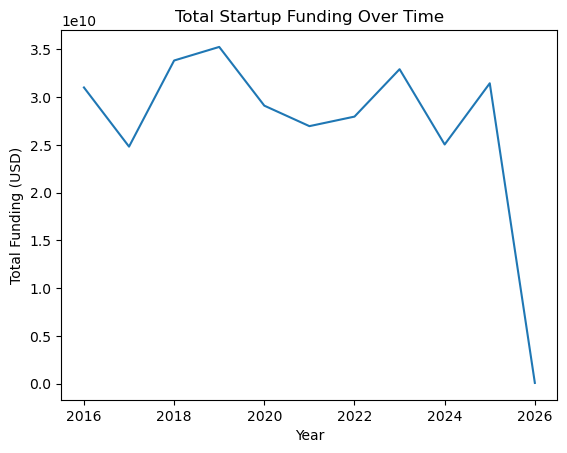

In [50]:
# =========================
# STEP 7 — CHART: FUNDING OVER TIME
# =========================

funding_by_year = df.groupby("Year")["Amount Raised (USD)"].sum().sort_index()

print(funding_by_year)

# Create ONE figure + axis
fig, ax = plt.subplots()

# Plot on that axis
funding_by_year.plot(ax=ax)

# Titles and labels
ax.set_title("Total Startup Funding Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Total Funding (USD)")

# Save BEFORE showing
fig.savefig(
    f"{OUTPUT_DIR}/01_funding_over_time.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# Show only once
plt.show()



Year
2016    207
2017    206
2018    192
2019    220
2020    201
2021    179
2022    182
2023    211
2024    179
2025    221
2026      2
dtype: int64


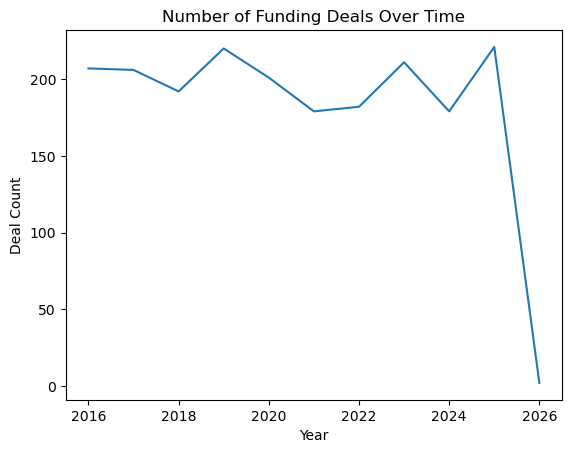

In [29]:
# =========================
# STEP 8 — CHART: DEAL COUNT OVER TIME
# =========================
deals_by_year = df.groupby("Year").size().sort_index()

print(deals_by_year)

plt.figure()
deals_by_year.plot()
plt.title("Number of Funding Deals Over Time")
plt.xlabel("Year")
plt.ylabel("Deal Count")
plt.show()


Industry
AI            4.370760e+10
Education     4.000036e+10
Tech          3.960517e+10
Finance       3.827173e+10
Health        3.622630e+10
E-commerce    3.369096e+10
SaaS          3.368749e+10
Gaming        3.324961e+10
Name: Amount Raised (USD), dtype: float64


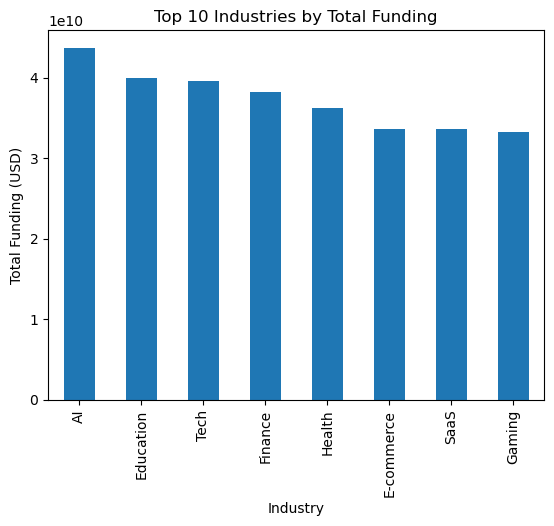

In [51]:
# =========================
# STEP 9 — CHART: TOP INDUSTRIES
# =========================

top_industries = (
    df.groupby("Industry")["Amount Raised (USD)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_industries)

fig, ax = plt.subplots()

top_industries.plot(kind="bar", ax=ax)

ax.set_title("Top 10 Industries by Total Funding")
ax.set_xlabel("Industry")
ax.set_ylabel("Total Funding (USD)")

fig.savefig(
    f"{OUTPUT_DIR}/02_top_industries.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()




Average funding by stage:
 Funding Stage
Seed        2.711334e+05
Series A    5.395442e+06
Series B    2.937603e+07
Series C    1.266167e+08
IPO         5.814410e+08
Name: Amount Raised (USD), dtype: float64

Total funding by stage:
 Funding Stage
IPO         2.302506e+11
Series C    5.368546e+10
Series B    1.230856e+10
Series A    2.093431e+09
Seed        1.011328e+08
Name: Amount Raised (USD), dtype: float64


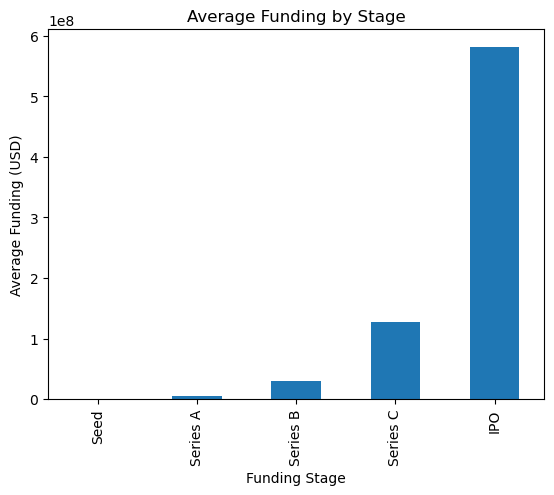

In [52]:
# =========================
# STEP 10 — CHART: FUNDING STAGES
# =========================

stage_avg = df.groupby("Funding Stage")["Amount Raised (USD)"].mean().sort_values()
stage_total = df.groupby("Funding Stage")["Amount Raised (USD)"].sum().sort_values(ascending=False)

print("Average funding by stage:\n", stage_avg)
print("\nTotal funding by stage:\n", stage_total)

fig, ax = plt.subplots()

stage_avg.plot(kind="bar", ax=ax)

ax.set_title("Average Funding by Stage")
ax.set_xlabel("Funding Stage")
ax.set_ylabel("Average Funding (USD)")

fig.savefig(
    f"{OUTPUT_DIR}/03_funding_stages.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()



Country
Canada         4.191562e+10
Netherlands    3.950844e+10
France         3.930798e+10
Germany        3.755725e+10
USA            3.690023e+10
India          3.618996e+10
UK             3.389847e+10
Australia      3.316127e+10
Name: Amount Raised (USD), dtype: float64


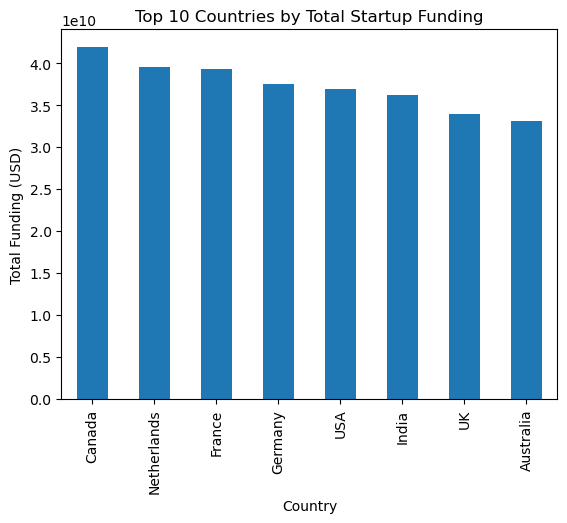

In [53]:
# =========================
# STEP 11 — CHART: TOP COUNTRIES
# =========================

top_countries = (
    df.groupby("Country")["Amount Raised (USD)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_countries)

fig, ax = plt.subplots()

top_countries.plot(kind="bar", ax=ax)

ax.set_title("Top 10 Countries by Total Startup Funding")
ax.set_xlabel("Country")
ax.set_ylabel("Total Funding (USD)")

fig.savefig(
    f"{OUTPUT_DIR}/04_top_countries.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()




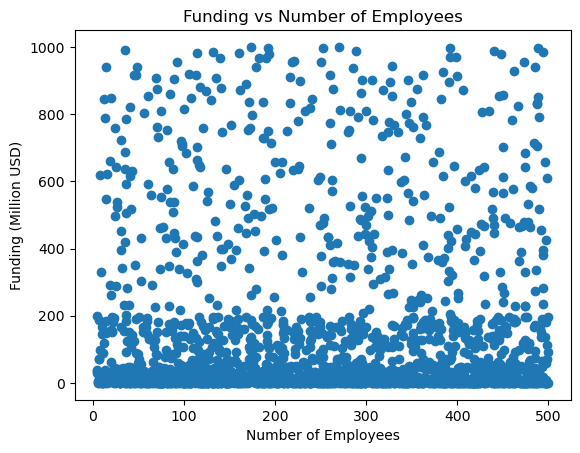

In [33]:
# =========================
# STEP 12 — CHART: FUNDING vs EMPLOYEES
# =========================
plt.figure()
plt.scatter(df["Number of Employees"], df["Funding_Million"])
plt.title("Funding vs Number of Employees")
plt.xlabel("Number of Employees")
plt.ylabel("Funding (Million USD)")
plt.show()


In [54]:
import os
print(os.listdir(OUTPUT_DIR))

['01_funding_over_time.png', '02_top_industries.png', '03_funding_stages.png', '04_top_countries.png']


In [ ]:
# =========================
# STEP 13 — INSIGHTS 
# =========================

# 1) Peak funding year
peak_year = funding_by_year.idxmax()
print("Peak funding year:", peak_year, "| Total:", funding_by_year.loc[peak_year])

# 2) Top industry
top_industry = df.groupby("Industry")["Amount Raised (USD)"].sum().idxmax()
print("Top funded industry:", top_industry)

# 3) Top country
top_country = df.groupby("Country")["Amount Raised (USD)"].sum().idxmax()
print("Top funded country:", top_country)

# 4) Stage with highest average ticket
best_stage_avg = df.groupby("Funding Stage")["Amount Raised (USD)"].mean().idxmax()
print("Highest avg funding stage:", best_stage_avg)

# 5) Stage that dominates total volume
best_stage_total = df.groupby("Funding Stage")["Amount Raised (USD)"].sum().idxmax()
print("Highest total funding stage:", best_stage_total)


Peak funding year: 2019 | Total: 35253160994.0
Top funded industry: AI
Top funded country: Canada
Highest avg funding stage: IPO
Highest total funding stage: IPO


In [35]:
# =========================
# FINAL — KEY INSIGHTS
# =========================

print("KEY INSIGHTS FROM THE ANALYSIS:\n")

print("1) Venture capital funding is not stable: it shows clear boom and slowdown cycles over time.")
print("2) Innovation investment is highly concentrated in a few industries such as AI, FinTech, and HealthTech.")
print("3) Late-stage rounds (Series B/C) dominate total capital, while Seed rounds dominate deal volume.")
print("4) Startup ecosystems remain geographically concentrated, with a few countries leading global VC flows.")
print("5) Some startups raise large funding amounts with relatively small teams, highlighting capital-efficient growth models.")


KEY INSIGHTS FROM THE ANALYSIS:

1) Venture capital funding is not stable: it shows clear boom and slowdown cycles over time.
2) Innovation investment is highly concentrated in a few industries such as AI, FinTech, and HealthTech.
3) Late-stage rounds (Series B/C) dominate total capital, while Seed rounds dominate deal volume.
4) Startup ecosystems remain geographically concentrated, with a few countries leading global VC flows.
5) Some startups raise large funding amounts with relatively small teams, highlighting capital-efficient growth models.


In [36]:
# =========================
# FINAL — RECOMMENDATIONS
# =========================

print("RECOMMENDATIONS:\n")

print("1) Investors should monitor emerging innovation sectors (AI, ClimateTech) where capital inflows accelerate.")
print("2) Policymakers should strengthen startup ecosystems outside dominant hubs to improve funding distribution.")
print("3) Startups should strategically time fundraising rounds based on macro VC cycles.")
print("4) Early-stage founders should focus on efficiency, as high funding does not always require large headcount.")


RECOMMENDATIONS:

1) Investors should monitor emerging innovation sectors (AI, ClimateTech) where capital inflows accelerate.
2) Policymakers should strengthen startup ecosystems outside dominant hubs to improve funding distribution.
3) Startups should strategically time fundraising rounds based on macro VC cycles.
4) Early-stage founders should focus on efficiency, as high funding does not always require large headcount.


In [55]:
# =========================
# FIRST PORTFOLIO PROJECT — COMPLETE ✨
# =========================

print("\n" + "="*70)
print("🚀 Startup Funding & VC Trends Analysis Finished!")
print("My first portfolio project — and the first building block of my Data Analyst path.")
print("From curiosity → to code → to insights.")
print("The journey has just begun 🌱📊")
print("\n— Maroua Safaa")
print("="*70)


🚀 Startup Funding & VC Trends Analysis Finished!
My first portfolio project — and the first building block of my Data Analyst path.
From curiosity → to code → to insights.
The journey has just begun 🌱📊

— Maroua Safaa
